- yfinance 설치

In [5]:
!pip install yfinance

Defaulting to user installation because normal site-packages is not writeable


- 라이브러리 임포트

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import koreanize_matplotlib

- 애플의 1년치 데이터 다운로드 후 일부데이터 출력, 데이터 크기 출력
- 야후파이낸스에서 지정한 티커(종목코드) 기준
- 애플의 티커는 AAPL

In [7]:
# 애플(AAPL)의 1년치 데이터 다운로드
# (삼성전자를 보고 싶다면 '005930.KS'를 넣으면 됩니다)
df = yf.download('AAPL', period='1y')

# 데이터가 잘 왔는지 확인 (날짜, 시가, 고가, 저가, 종가, 거래량 등이 보입니다)


[*********************100%***********************]  1 of 1 completed


In [8]:
df.head()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2025-03-04,234.906174,239.028223,233.661598,236.678463,53798100
2025-03-05,234.716995,235.523478,228.235236,234.398377,47227600
2025-03-06,234.308777,236.827797,232.148195,233.422640,45170400
2025-03-07,238.032562,240.322569,233.741253,234.089740,46273600
2025-03-10,226.492859,235.135200,223.247011,234.517881,72071200


In [9]:
df.tail()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2026-02-25,274.230011,274.940002,271.049988,271.779999,33714300
2026-02-26,272.950012,276.109985,270.799988,274.950012,32345100
2026-02-27,264.179993,272.809998,262.890015,272.809998,72366500
2026-03-02,264.720001,266.529999,260.200012,262.410004,41827900
2026-03-03,263.750000,265.559998,260.130005,263.480011,37994695


- 컬럼명과 인덱스 출력

In [10]:
df.columns

MultiIndex([( 'Close', 'AAPL'),
            (  'High', 'AAPL'),
            (   'Low', 'AAPL'),
            (  'Open', 'AAPL'),
            ('Volume', 'AAPL')],
           names=['Price', 'Ticker'])

In [11]:
df.index

DatetimeIndex(['2025-03-04', '2025-03-05', '2025-03-06', '2025-03-07',
               '2025-03-10', '2025-03-11', '2025-03-12', '2025-03-13',
               '2025-03-14', '2025-03-17',
               ...
               '2026-02-18', '2026-02-19', '2026-02-20', '2026-02-23',
               '2026-02-24', '2026-02-25', '2026-02-26', '2026-02-27',
               '2026-03-02', '2026-03-03'],
              dtype='datetime64[ns]', name='Date', length=251, freq=None)

- 결측치 확인
- 결측치 채우기( 앞의 데이터로 채우기 : ffill , 뒤의 데이터로 채우기 : bfill )

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 251 entries, 2025-03-04 to 2026-03-03
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, AAPL)   251 non-null    float64
 1   (High, AAPL)    251 non-null    float64
 2   (Low, AAPL)     251 non-null    float64
 3   (Open, AAPL)    251 non-null    float64
 4   (Volume, AAPL)  251 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 11.8 KB


In [15]:
# 빈칸(결측치)이 있는지 확인
print(df.isnull().sum())

# 만약 빈칸이 있다면, 바로 전날의 가격으로 채워넣기 (ffill: forward fill)
df = df.ffill()

# 데이터 정보 최종 확인 (날짜 타입, 숫자 타입 등이 맞는지 점검)
df.info()

Price   Ticker
Close   AAPL      0
High    AAPL      0
Low     AAPL      0
Open    AAPL      0
Volume  AAPL      0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 251 entries, 2025-03-04 to 2026-03-03
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, AAPL)   251 non-null    float64
 1   (High, AAPL)    251 non-null    float64
 2   (Low, AAPL)     251 non-null    float64
 3   (Open, AAPL)    251 non-null    float64
 4   (Volume, AAPL)  251 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 11.8 KB


- 종가를 기준으로 이동평균 계산
- 이동평균은 판다스의 rolling(개수).mean() 함수 사용

In [16]:
# 종가(Close)를 기준으로 이동평균 계산

# 20일 이동평균선 (창문을 20개씩 옆으로 밀며 평균 구하기)
df['MA20'] =  df['Close'].rolling(window=20).mean()

# 60일 이동평균선
df['MA60'] =  df['Close'].rolling(window=60).mean()

# 계산된 결과 확인 (앞부분 20일은 데이터가 부족해 NaN으로 나옵니다)
df.head(30)

Price,Close,High,Low,Open,Volume,MA20,MA60
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,,
Date,,,,,,,
2025-03-04,234.906174,239.028223,233.661598,236.678463,53798100,NaN,NaN
2025-03-05,234.716995,235.523478,228.235236,234.398377,47227600,NaN,NaN
2025-03-06,234.308777,236.827797,232.148195,233.422640,45170400,NaN,NaN
2025-03-07,238.032562,240.322569,233.741253,234.089740,46273600,NaN,NaN
2025-03-10,226.492859,235.135200,223.247011,234.517881,72071200,NaN,NaN
2025-03-11,219.881668,224.859971,216.506379,222.838781,76137400,NaN,NaN
2025-03-12,216.038406,220.787711,213.977397,219.184697,62547500,NaN,NaN
2025-03-13,208.770096,215.899029,207.515569,215.012892,61368300,NaN,NaN


In [17]:
df.tail()

Price,Close,High,Low,Open,Volume,MA20,MA60
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,,
Date,,,,,,,
2026-02-25,274.230011,274.940002,271.049988,271.779999,33714300,267.472775,267.929976
2026-02-26,272.950012,276.109985,270.799988,274.950012,32345100,268.310262,267.835988
2026-02-27,264.179993,272.809998,262.890015,272.809998,72366500,268.617334,267.525065
2026-03-02,264.720001,266.529999,260.200012,262.410004,41827900,268.891463,267.171691
2026-03-03,263.750000,265.559998,260.130005,263.480011,37994695,268.591083,266.836118


- 시각화
- 실제 주가와 20일 이동평균선, 60일 이동평균선 출력
- 범례와 격자 출력

In [4]:
 # 그래프 크기 키우기

# 1. 실제 주가 (얇은 선)


# 2. 20일 이동평균선 (주황색, 단기 추세)


# 3. 60일 이동평균선 (파란색, 중기 추세)


# 그래프 꾸미기


Text(0.5, 1.0, '애플의 1년 주가변동 추이')

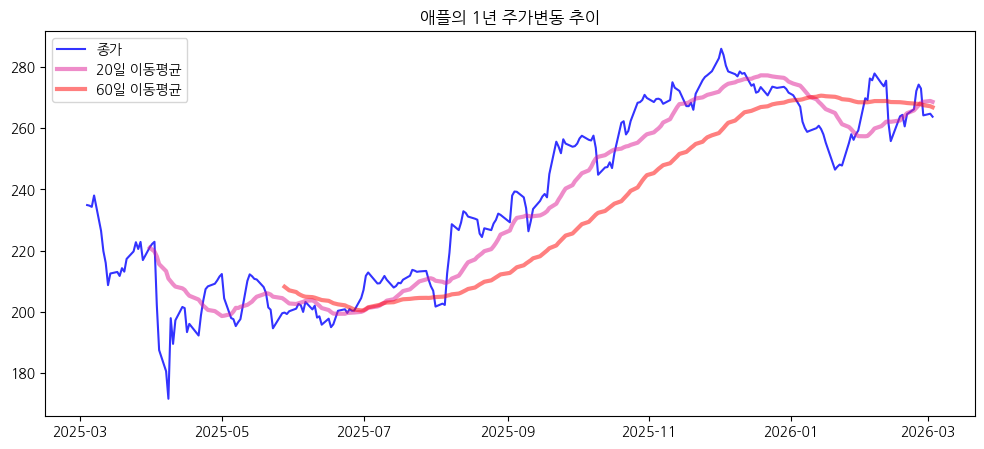

In [34]:
plt.figure(figsize=(12,5))
plt.plot(df['Close'], alpha=0.8, label='종가', color='b')
plt.plot(df['MA20'], alpha=0.5, label='20일 이동평균', color='#DE1A95', linewidth=3)
plt.plot(df['MA60'], alpha=0.5, label='60일 이동평균', color='r', linewidth=3)
plt.legend()
plt.title('애플의 1년 주가변동 추이')